#### HCI Project Spring 2026

Rob Rood, Mamata Joshi, Afsana Tasnim Juha

Dataset: Our project is utilizing a Covid-19 dataset. This dataset contains over 1 million rows detailing cases, outcomes and demographic data. Note, we are reducing the working set to 100_000 rows so that Python won't crash searching through all that data.

Problem: The reason we think this dataset is interesting as a Human-centered AI problem, is because of all the controversy over whether or not the restrictions applied during the epidemic were worth the economic effects on the nation and world. Including co-morbidities with the cases of death, allows for calculations of how deadly Covid was in its initial vector. Will it kill people that only have other diseases weakening their immune systems?

Target Users: Doctors, Nurses, Healthcare Statisticians and regular people who are concerned about their own situation.

Limitations: Extending this problem to the entire world will likely only be done via inference because the data is US based. Also, for an individual using this dataset, it can be comforting to apply the statistics in a "am I likely to have a negative outcome?" way. However, statistics doesn't always apply well to individuals, so that is a limitation in using the dataset in this manner.

Machine Learning Model: This notebook contains an instance of the 

In [1]:
import sys
from pathlib import Path

# Get the notebook's directory and navigate to project roots
notebook_dir = Path('.').resolve()
repo_root = notebook_dir.parent.parent
hci_package = repo_root / 'HCI'

sys.path.insert(0, str(hci_package))
sys.path.insert(0, str(repo_root))

In [2]:
# packages needed for this notebook
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix
)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# dataset handling methods
from eda.data_ops import load_csv_data, get_dataset_summary


#### Load the Preprocessed data

In the EDA notebook, we did extensive dataset preprocessing. We saved the results of this processing so we could use it in this notebook.

In [3]:
PREPROCESSED_DATA = hci_package / "eda/Preprocessed_Covid19.csv"
covid_df = load_csv_data(PREPROCESSED_DATA, nrows=100_000)

get_dataset_summary(covid_df)

--- Dataset Summary ---
Rows: 99768 | Columns: 24
   Unnamed: 0  USMER  MEDICAL_UNIT  SEX  PATIENT_TYPE   DATE_DIED  INTUBED  \
0           0      2             1    1             1  2020-05-03      NaN   
1           1      2             1    0             1  2020-06-03      NaN   
2           2      2             1    0             2  2020-06-09      1.0   
3           3      2             1    1             1  2020-06-12      NaN   
4           4      2             1    0             1  2020-06-21      NaN   

   PNEUMONIA  AGE  DIABETES  ...  OTHER_DISEASE  CARDIOVASCULAR  OBESITY  \
0        1.0   65       0.0  ...            0.0             0.0      0.0   
1        1.0   72       0.0  ...            0.0             0.0      1.0   
2        0.0   55       1.0  ...            0.0             0.0      0.0   
3        0.0   53       0.0  ...            0.0             0.0      0.0   
4        0.0   68       1.0  ...            0.0             0.0      0.0   

   RENAL_CHRONIC  TOBACC

#### Last bit o' cleaning

XGBoost can't handle date columns so I need to drop 'DATE_DIED' and 'DEATH_MONTH' from the data.

Another interesting data effect is the 'CLASIFFICATION_FINAL' column. Since it is 1 for had covid, 0 is didn't, it's presence skews the data so that the model can use a single column to predict outcomes and thus get perfect results. So in order to remove this side effect on the model, I am dropping it as well.

In [4]:
# Drop non-predictive / leakage columns
covid_df.drop(columns=['Unnamed: 0', 'DATE_DIED', 'DEATH_MONTH',
                 'CLASIFFICATION_FINAL'], inplace=True)

print(f"Dataset shape : {covid_df.shape}")
print(f"Columns       : {covid_df.columns.tolist()}\n")

Dataset shape : (99768, 20)
Columns       : ['USMER', 'MEDICAL_UNIT', 'SEX', 'PATIENT_TYPE', 'INTUBED', 'PNEUMONIA', 'AGE', 'DIABETES', 'COPD', 'ASTHMA', 'INMSUPR', 'HIPERTENSION', 'OTHER_DISEASE', 'CARDIOVASCULAR', 'OBESITY', 'RENAL_CHRONIC', 'TOBACCO', 'ICU', 'DIED', 'COVID_POSITIVE']



In [5]:
TARGET   = 'COVID_POSITIVE'
FEATURES = [c for c in covid_df.columns if c != TARGET]

X = covid_df[FEATURES].copy()
y = covid_df[TARGET].copy()

print("Target distribution:")
print(y.value_counts(), "\n")

Target distribution:
COVID_POSITIVE
1    76693
0    23075
Name: count, dtype: int64 



In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size : {X_train.shape[0]:,}  |  Test size : {X_test.shape[0]:,}\n")

Train size : 79,814  |  Test size : 19,954



In [7]:
# Initialize the 3rd model
# use scale_pos_weight if your 'at risk' class is much smaller than 'low risk'
model_xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Fit to your training data
model_xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [8]:

y_pred  = model_xgb.predict(X_test)
y_proba = model_xgb.predict_proba(X_test)[:, 1]


acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
cm   = confusion_matrix(y_test, y_pred)
fi   = pd.Series(model_xgb.feature_importances_,
                 index=FEATURES).sort_values(ascending=False)

print("=" * 45)
print("  EVALUATION RESULTS")
print("=" * 45)
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print("=" * 45)

  EVALUATION RESULTS
  Accuracy  : 0.8130
  Precision : 0.8464
  Recall    : 0.9246
  F1-Score  : 0.8838



Visualization saved as 'xgboost_covid_results.png'


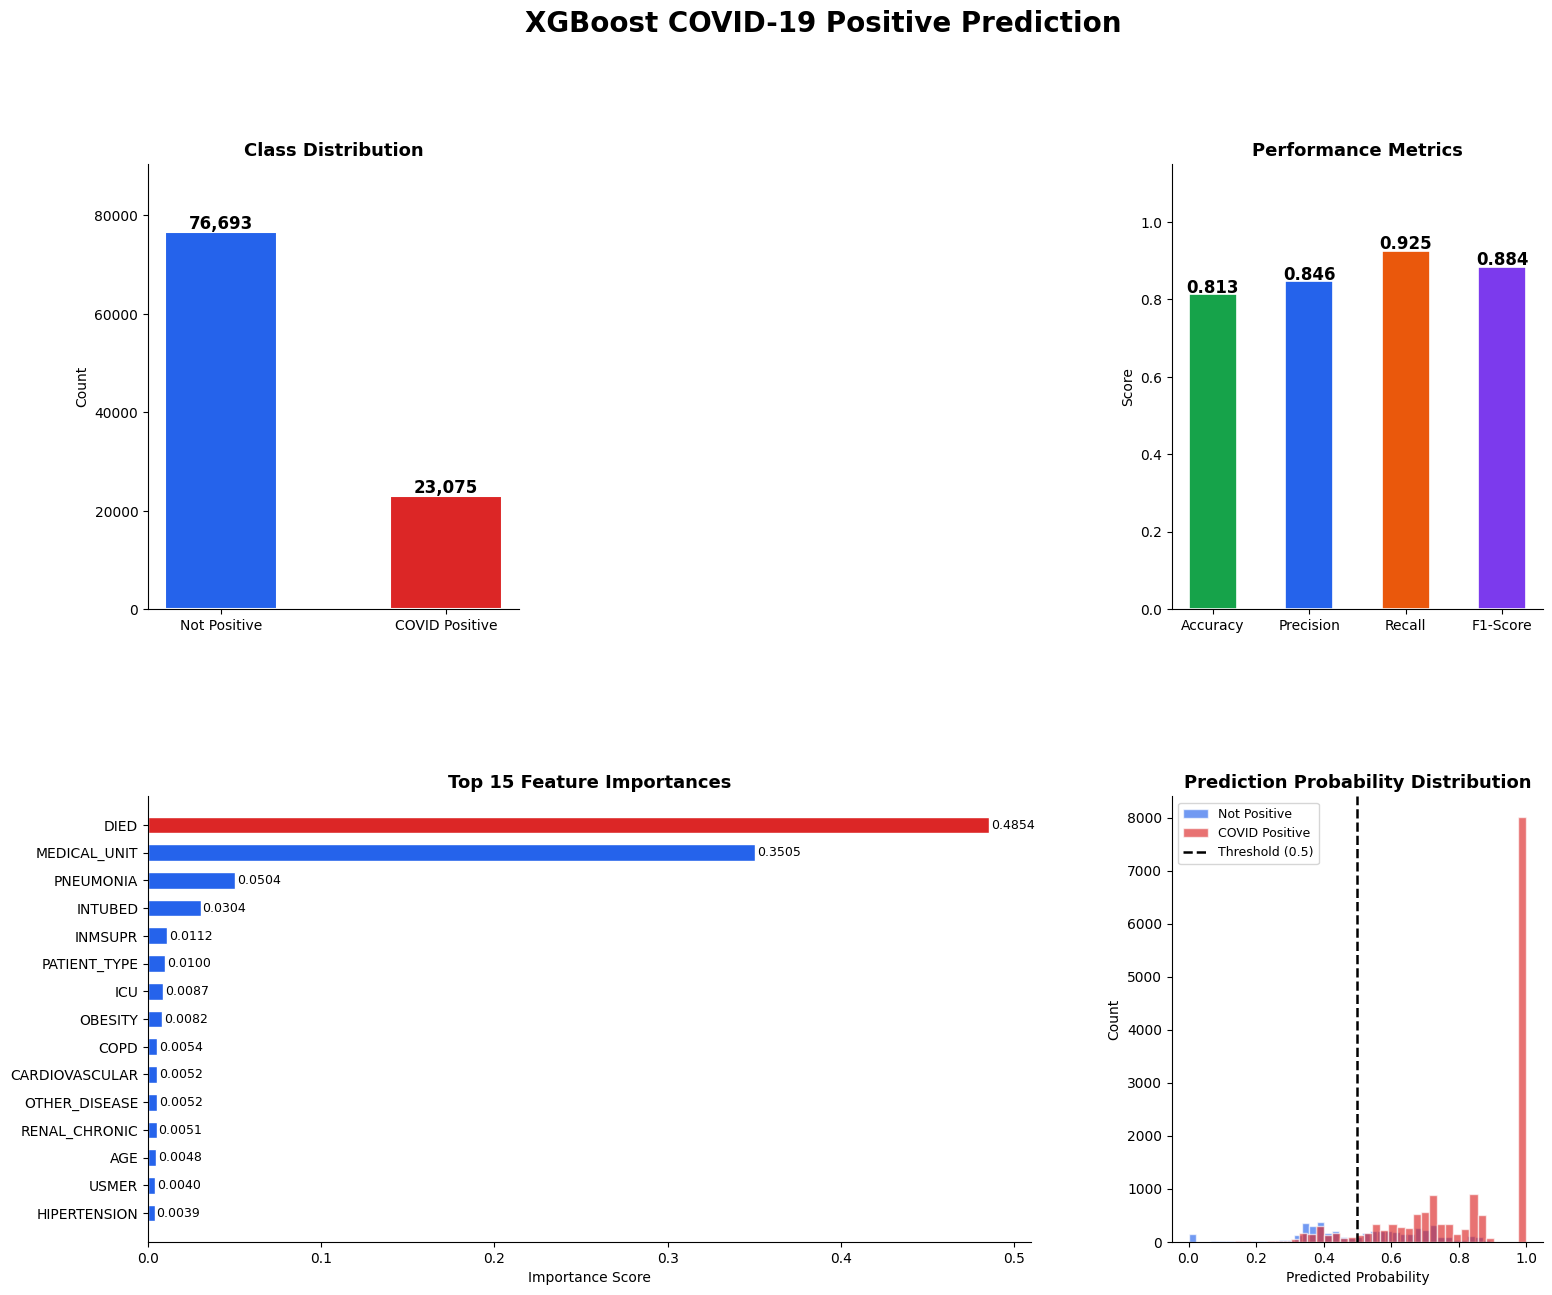

In [9]:

plt.rcParams.update({
    'font.family'       : 'DejaVu Sans',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'figure.facecolor'  : 'white'
})
BLUE, RED, GREEN, ORANGE, PURPLE = '#2563EB', '#DC2626', '#16A34A', '#EA580C', '#7C3AED'

fig = plt.figure(figsize=(18, 14))
fig.suptitle('XGBoost COVID-19 Positive Prediction',
             fontsize=20, fontweight='bold', y=0.99)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.38)

# ── Plot 1: Class Distribution ───────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
counts = y.value_counts()
bars1  = ax1.bar(['Not Positive', 'COVID Positive'], counts.values,
                 color=[BLUE, RED], edgecolor='white', linewidth=1.5, width=0.5)
for b in bars1:
    ax1.text(b.get_x() + b.get_width()/2, b.get_height() + 500,
             f'{b.get_height():,}', ha='center', fontweight='bold', fontsize=12)
ax1.set_title('Class Distribution', fontsize=13, fontweight='bold')
ax1.set_ylabel('Count')
ax1.set_ylim(0, max(counts.values) * 1.18)



# ── Plot 3: Performance Metrics Bar ──────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
metrics = {
    'Accuracy' : acc,
    'Precision': prec,
    'Recall'   : rec,
    'F1-Score' : f1
}
b3 = ax3.bar(list(metrics.keys()), list(metrics.values()),
             color=[GREEN, BLUE, ORANGE, PURPLE],
             edgecolor='white', linewidth=1.2, width=0.5)
for b in b3:
    ax3.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
             f'{b.get_height():.3f}', ha='center', fontsize=12, fontweight='bold')
ax3.set_title('Performance Metrics', fontsize=13, fontweight='bold')
ax3.set_ylim(0, 1.15)
ax3.set_ylabel('Score')

# ── Plot 4: Top 15 Feature Importances ───────────────────────────────────────
ax4 = fig.add_subplot(gs[1, :2])
top15      = fi.head(15)
bar_colors = [RED if i == 0 else BLUE for i in range(len(top15))]
bars4      = ax4.barh(top15.index[::-1], top15.values[::-1],
                      color=bar_colors[::-1], edgecolor='white', height=0.6)
for b in bars4:
    ax4.text(b.get_width() + 0.001, b.get_y() + b.get_height()/2,
             f'{b.get_width():.4f}', va='center', fontsize=9)
ax4.set_title('Top 15 Feature Importances', fontsize=13, fontweight='bold')
ax4.set_xlabel('Importance Score')

# ── Plot 5: Prediction Probability Distribution ───────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
ax5.hist(y_proba[y_test == 0], bins=40, alpha=0.65, color=BLUE,
         label='Not Positive', edgecolor='white')
ax5.hist(y_proba[y_test == 1], bins=40, alpha=0.65, color=RED,
         label='COVID Positive', edgecolor='white')
ax5.axvline(0.5, color='black', linestyle='--', lw=1.8, label='Threshold (0.5)')
ax5.set_xlabel('Predicted Probability')
ax5.set_ylabel('Count')
ax5.legend(fontsize=9)
ax5.set_title('Prediction Probability Distribution', fontsize=13, fontweight='bold')

plt.savefig('xgboost_covid_results.png', dpi=150,
            bbox_inches='tight', facecolor='white')
print("\nVisualization saved as 'xgboost_covid_results.png'")